Save directory: C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\neel_dw\20260503_02
Mesh: [256 256   1] cells  |  pixel size: 5 nm
Domain size: 1280 x 1280 nm
Theoretical domain wall width: 13.6 nm
Running OOMMF (ExeOOMMFRunner)[2026-05-03T14:13:50]... (6.7 s)
Relaxation done.
Mz range: -580000.0 ~ 580000.0 A/m
Array shape: (256, 256)


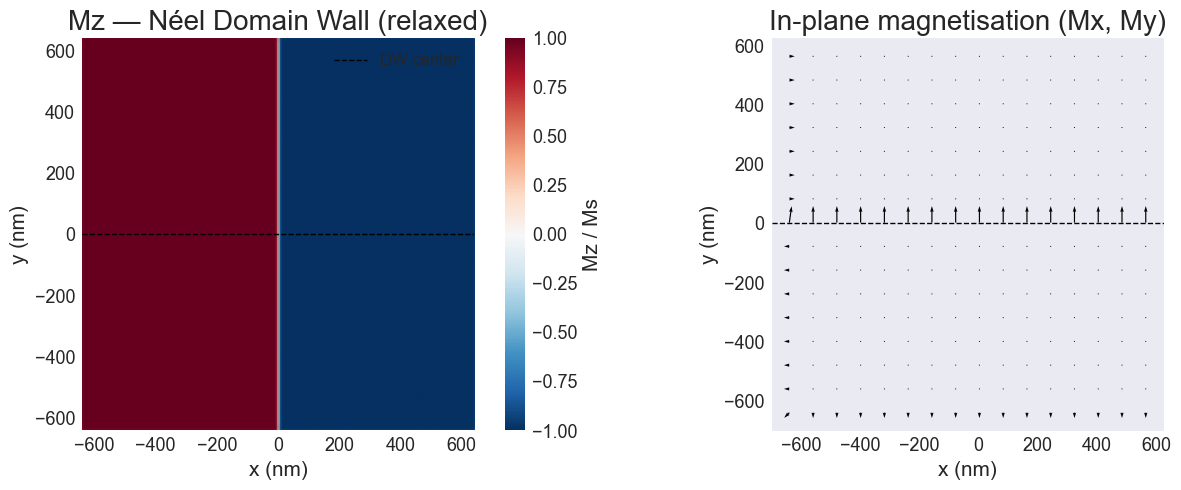

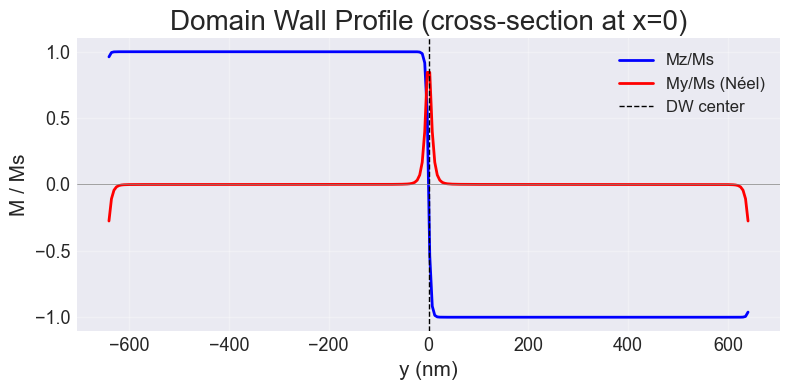

Bz range at 50 nm: -302.677 ~ 302.677 mT
Bz mean: 0.000 mT
Bz at center (y=0): -9.742 mT
Bz at bottom edge:  10.956 mT
Bz at top edge:     -10.956 mT


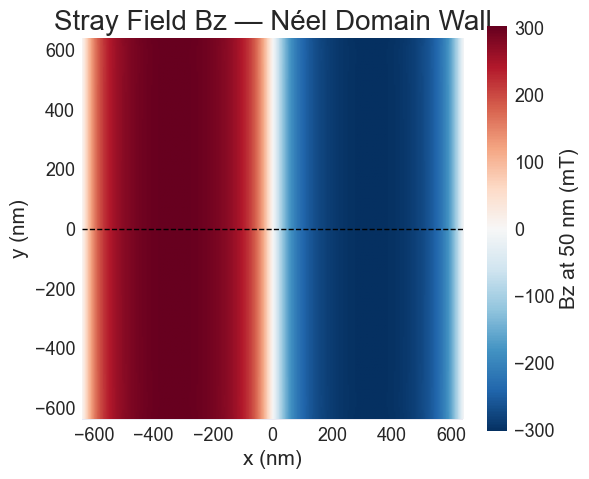

Saved:
  C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\neel_dw\20260503_02/Bz_NV_neel_dw.npy    shape=(256, 256)
  C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\neel_dw\20260503_02/Mz_true_neel_dw.npy   shape=(256, 256)
JSON saved.

=== Pipeline integration check ===
Bz_NV shape : (256, 256)  (expected (256, 256))
Mz_true shape: (256, 256)  (expected (256, 256))
Bz_NV dtype : float64
Mz_true dtype: float64

Replace in your Notebook Cell 2:
  Bz_NV  = np.load(r"C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\neel_dw\20260503_02\Bz_NV_neel_dw.npy")
  Mz_true = np.load(r"C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\neel_dw\20260503_02\Mz_true_neel_dw.npy")


In [1]:
# ============================================================
# Ubermag Néel Domain Wall Simulation — Local Windows
# Single centered Néel domain wall, wall perpendicular to y-axis
# Left (+Mz) | DW at y=0 | Right (−Mz)
# Output: Bz_NV_neel_dw.npy, Mz_true_neel_dw.npy
# Compatible with Ubermag_Model_Verification pipeline
# ============================================================
# Author: Yue Yu, TU Dresden / ct.qmat
# ============================================================

# ── Cell 1: Imports ──────────────────────────────────────────
import discretisedfield as df
import micromagneticmodel as mm
import oommfc as oc
import numpy as np
import matplotlib.pyplot as plt
import json, os
from datetime import datetime

# ── Cell 2: Paths ────────────────────────────────────────────
CASE     = "neel_dw"
base_dir = r"C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag"

date_str = datetime.now().strftime("%Y%m%d")
idx = 1
while os.path.exists(os.path.join(base_dir, CASE, f"{date_str}_{idx:02d}")):
    idx += 1

case_dir = os.path.join(base_dir, CASE, f"{date_str}_{idx:02d}")
os.makedirs(case_dir, exist_ok=True)
print("Save directory:", case_dir)

# ── Cell 3: Geometry ─────────────────────────────────────────
Lx   = 256 * 5e-9   # 1280 nm
Ly   = 256 * 5e-9   # 1280 nm
Lz   = 5e-9
cell = (5e-9, 5e-9, 5e-9)
z_NV = 50e-9

mesh = df.Mesh(
    p1=(-Lx/2, -Ly/2, 0),
    p2=( Lx/2,  Ly/2, Lz),
    cell=cell
)
print(f"Mesh: {mesh.n} cells  |  pixel size: {cell[0]*1e9:.0f} nm")
print(f"Domain size: {Lx*1e9:.0f} x {Ly*1e9:.0f} nm")

# ── Cell 4: Material parameters (Co/Pt, Néel DW) ─────────────
Ms = 5.8e5    # A/m
A  = 1.5e-11  # J/m
D  = 3.0e-3   # J/m²  — interfacial DMI (Cnv_z → Néel type)
K  = 0.8e6    # J/m³  — uniaxial anisotropy (easy OOP)

# 理论畴壁宽度 δ = π√(A/K) ≈ 13 nm
dw_width = np.pi * np.sqrt(A / K)
print(f"Theoretical domain wall width: {dw_width*1e9:.1f} nm")

# ── Cell 5: Initial magnetisation ────────────────────────────
# 畴壁垂直于 y 轴，位于 y=0 处
# y < 0 → +Mz,  y > 0 → −Mz
# 面内分量沿 y 方向（Néel 型）

def m_neel_dw(pos):
    x, y, _ = pos
    mz  = -np.tanh(y / dw_width)
    mxy = np.sqrt(max(1.0 - mz**2, 0.0))
    mx  = 0.0
    my  = mxy   # 面内分量沿 y 方向
    return (mx * Ms, my * Ms, mz * Ms)

# ── Cell 6: Build system & relax ─────────────────────────────
system = mm.System(name="neel_dw")
system.energy = (
    mm.Exchange(A=A)
    + mm.DMI(D=D, crystalclass="Cnv_z")
    + mm.UniaxialAnisotropy(K=K, u=(0, 0, 1))
    + mm.Demag()
)
system.m = df.Field(mesh, nvdim=3, value=m_neel_dw, norm=Ms)

md = oc.MinDriver()
md.drive(system)
print("Relaxation done.")

# ── Cell 7: Extract Mx, My, Mz ───────────────────────────────
m_sel = system.m.sel(z=Lz / 2)
Mx = np.squeeze(m_sel.x.array)
My = np.squeeze(m_sel.y.array)
Mz = np.squeeze(m_sel.z.array)
nx, ny = Mz.shape
print(f"Mz range: {Mz.min():.1f} ~ {Mz.max():.1f} A/m")
print(f"Array shape: {Mz.shape}")

# ── Cell 8: Plot Mz + in-plane ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(
    Mz / Ms,
    extent=[-Lx/2*1e9, Lx/2*1e9, -Ly/2*1e9, Ly/2*1e9],
    origin="lower", cmap="RdBu_r", vmin=-1, vmax=1
)
plt.colorbar(im0, ax=axes[0], label="Mz / Ms")
axes[0].set_title("Mz — Néel Domain Wall (relaxed)")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")
axes[0].axhline(0, color='k', linewidth=1, linestyle='--', label='DW center')
axes[0].legend()

step = 16
x_arr = np.linspace(-Lx/2*1e9, Lx/2*1e9, nx)
y_arr = np.linspace(-Ly/2*1e9, Ly/2*1e9, ny)
X, Y  = np.meshgrid(x_arr[::step], y_arr[::step], indexing="ij")
axes[1].quiver(X, Y,
               Mx[::step, ::step] / Ms,
               My[::step, ::step] / Ms,
               scale=20, width=0.003)
axes[1].set_aspect("equal")
axes[1].set_title("In-plane magnetisation (Mx, My)")
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("y (nm)")
axes[1].axhline(0, color='k', linewidth=1, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(case_dir, "Mz_neel_dw.png"), dpi=150)
plt.show()

# ── Cell 9: DW profile along y (畴壁截面) ────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
mid_x = nx // 2
y_nm  = np.linspace(-Ly/2*1e9, Ly/2*1e9, ny)
ax.plot(y_nm, Mz[mid_x, :] / Ms, 'b-', linewidth=2, label='Mz/Ms')
ax.plot(y_nm, My[mid_x, :] / Ms, 'r-', linewidth=2, label='My/Ms (Néel)')
ax.axvline(0, color='k', linewidth=1, linestyle='--', label='DW center')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel("y (nm)")
ax.set_ylabel("M / Ms")
ax.set_title("Domain Wall Profile (cross-section at x=0)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(case_dir, "DW_profile_neel_dw.png"), dpi=150)
plt.show()

# ── Cell 10: Compute Bz stray field ──────────────────────────
dx = cell[0]
dy = cell[1]
kx_arr  = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
ky_arr  = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
kx_grid, ky_grid = np.meshgrid(kx_arr, ky_arr, indexing="ij")
k = np.sqrt(kx_grid**2 + ky_grid**2)
k[0, 0] = 1e-12

Mx_k = np.fft.fft2(Mx)
My_k = np.fft.fft2(My)
Mz_k = np.fft.fft2(Mz)

mu0  = 4 * np.pi * 1e-7
Bz_k = mu0 / (2 * k) * (
    -1j * kx_grid * Mx_k
    - 1j * ky_grid * My_k
    + k * Mz_k
)

Bz_NV = np.real(np.fft.ifft2(Bz_k * np.exp(-k * z_NV)))

print(f"Bz range at {z_NV*1e9:.0f} nm: "
      f"{Bz_NV.min()*1e3:.3f} ~ {Bz_NV.max()*1e3:.3f} mT")
print(f"Bz mean: {Bz_NV.mean()*1e3:.3f} mT")
print(f"Bz at center (y=0): {Bz_NV[nx//2, ny//2]*1e3:.3f} mT")
print(f"Bz at bottom edge:  {Bz_NV[nx//2, 0]*1e3:.3f} mT")
print(f"Bz at top edge:     {Bz_NV[nx//2, -1]*1e3:.3f} mT")

# ── Cell 11: Plot Bz ─────────────────────────────────────────
vmax = np.percentile(np.abs(Bz_NV * 1e3), 99)

plt.figure(figsize=(6, 5))
im = plt.imshow(
    Bz_NV * 1e3,
    extent=[-Lx/2*1e9, Lx/2*1e9, -Ly/2*1e9, Ly/2*1e9],
    origin="lower", cmap="RdBu_r",
    vmin=-vmax, vmax=vmax
)
plt.colorbar(im, label="Bz at 50 nm (mT)")
plt.axhline(0, color='k', linewidth=1, linestyle='--')
plt.xlabel("x (nm)")
plt.ylabel("y (nm)")
plt.title("Stray Field Bz — Néel Domain Wall")
plt.tight_layout()
plt.savefig(os.path.join(case_dir, "Bz_neel_dw.png"), dpi=150)
plt.show()

# ── Cell 12: Save .npy ───────────────────────────────────────
np.save(os.path.join(case_dir, "Bz_NV_neel_dw.npy"), Bz_NV)
np.save(os.path.join(case_dir, "Mz_true_neel_dw.npy"), Mz)
print("Saved:")
print(f"  {case_dir}/Bz_NV_neel_dw.npy    shape={Bz_NV.shape}")
print(f"  {case_dir}/Mz_true_neel_dw.npy   shape={Mz.shape}")

# ── Cell 13: Save JSON ───────────────────────────────────────
synthetic_data = {
    "MagneticFieldImage (2D double array)": Bz_NV.tolist(),
    "PixleSizeX (double)": dx,
    "PixleSizeY (double)": dy,
    "NVTheta (double)": 0,
    "NVPhi (double)": 0,
    "NVHeight (double)": z_NV,
    "MagnetisationType (string)": "OOP",
    "SampleIdentification (string)": "Neel_DW",
    "MeasurementIdentification (string)": "Synthetic_Test",
    "MeasurementApparatus (string)": "Simulation"
}
with open(os.path.join(case_dir, "neel_dw.json"), "w") as f:
    json.dump(synthetic_data, f)
print("JSON saved.")

# ── Cell 14: Pipeline integration check ──────────────────────
Bz_check = np.load(os.path.join(case_dir, "Bz_NV_neel_dw.npy"))
Mz_check = np.load(os.path.join(case_dir, "Mz_true_neel_dw.npy"))
print("\n=== Pipeline integration check ===")
print(f"Bz_NV shape : {Bz_check.shape}  (expected (256, 256))")
print(f"Mz_true shape: {Mz_check.shape}  (expected (256, 256))")
print(f"Bz_NV dtype : {Bz_check.dtype}")
print(f"Mz_true dtype: {Mz_check.dtype}")
print(f"\nReplace in your Notebook Cell 2:")
print(f'  Bz_NV  = np.load(r"{case_dir}\\Bz_NV_neel_dw.npy")')
print(f'  Mz_true = np.load(r"{case_dir}\\Mz_true_neel_dw.npy")')